In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.bat_hd_system import BatHeadDirectionSystem, sphere_to_toroid
from grid_cells.plot_tools import angular_error, smooth_ts
import os
from concurrent.futures import ThreadPoolExecutor

DATA_DIR = "../simulation_data/hebb_alt"
PLOTS_DIR = "../plots/hebb_alt"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
T = 140
dt = 0.5e-3
n = 256
intrinsic_noise = 0
input_noise = 0
n_conj = (20, 10)
interval = 100


def split_flight_data(high_noise_bat_flight, split_time):    
    split_index = np.searchsorted(high_noise_bat_flight["time"], split_time)
    bat_flight_1 = {key: value[:split_index] for key, value in high_noise_bat_flight.items()}
    bat_flight_2 = {key: value[split_index:] for key, value in high_noise_bat_flight.items()}
    return bat_flight_1, bat_flight_2

low_noise_bat_flight, high_noise_bat_flight = split_flight_data(generate_bat_flight(T=T, dt=dt), split_time=40)


net = BatHeadDirectionSystem(
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
)
net_anchor = BatHeadDirectionSystem(
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    feedback_strength=2,
    learn_weights=False
)
net_anchor_learnt_weight = BatHeadDirectionSystem(
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    feedback_strength=2,
    learn_weights=True
)
net.warm_up(initial_dir=low_noise_bat_flight["dir_torus"][0])
net_anchor.warm_up(initial_dir=low_noise_bat_flight["dir_torus"][0])
net_anchor_learnt_weight.warm_up(initial_dir=low_noise_bat_flight["dir_torus"][0])

with ThreadPoolExecutor(max_workers=3) as executor:
    no_anchor_future = executor.submit(
        net.run_simulation, low_noise_bat_flight["dir_vel"], interval=interval, verbose=False
    )
    anchor_future = executor.submit(
        net_anchor.run_simulation,
        low_noise_bat_flight["dir_vel"],
        dir=low_noise_bat_flight["dir_sphere"],
        save_weights=False,
        interval=interval,
        verbose=False,
    )

    learned_anchor_future = executor.submit(
        net_anchor_learnt_weight.run_simulation,
        low_noise_bat_flight["dir_vel"],
        dir=low_noise_bat_flight["dir_sphere"],
        save_weights=False,
        interval=interval,
        verbose=True,
    )

    no_anchor_future.result()
    anchor_future.result()
    learned_anchor_future.result()


100%|██████████| 279999/279999 [00:19<00:00, 14642.15it/s]


Ran warm up for 140 steps
Ran warm up for 140 steps
Ran warm up for 140 steps


Running Simulation Steps: 100%|██████████| 80000/80000 [01:21<00:00, 982.98it/s] 


In [3]:
intrinsic_noise = 0.01
input_noise = 1

net.set_noise(intrinsic_noise=intrinsic_noise, input_noise=input_noise)
net_anchor.set_noise(intrinsic_noise=intrinsic_noise, input_noise=input_noise)
net_anchor_learnt_weight.set_noise(intrinsic_noise=intrinsic_noise, input_noise=input_noise)




with ThreadPoolExecutor(max_workers=3) as executor:
    no_anchor_future = executor.submit(
        net.run_simulation, high_noise_bat_flight["dir_vel"], interval=interval, verbose=False
    )

    anchor_future = executor.submit(
        net_anchor.run_simulation,
        high_noise_bat_flight["dir_vel"],
        dir=high_noise_bat_flight["dir_sphere"],
        save_weights=False,
        interval=interval,
        verbose=False,
    )

    learned_anchor_future = executor.submit(
        net_anchor_learnt_weight.run_simulation,
        high_noise_bat_flight["dir_vel"],
        dir=high_noise_bat_flight["dir_sphere"],
        save_weights=True,
        interval=interval,
        verbose=True,
    )

    recording = no_anchor_future.result()
    recording_anchor = anchor_future.result()
    recording_learnt_anchor = learned_anchor_future.result()


Running Simulation Steps: 100%|██████████| 200000/200000 [03:33<00:00, 934.65it/s] 


In [4]:
np.savez(os.path.join(DATA_DIR, "recording"), **recording)
np.savez(os.path.join(DATA_DIR, "recording_anchor"), **recording_anchor)
np.savez(os.path.join(DATA_DIR, "recording_learnt_anchor"), **recording_learnt_anchor)


In [5]:
np.mean(
    np.abs(
        angular_error(
            recording_anchor["decoded_angle"], high_noise_bat_flight["dir_torus"][::interval]
        )
    ),
    axis=0,
),  np.mean(
    np.abs(
        angular_error(recording_learnt_anchor["decoded_angle"], high_noise_bat_flight["dir_torus"][::interval])
    ),
    axis=0,
),np.mean(
    np.abs(
        angular_error(recording["decoded_angle"], high_noise_bat_flight["dir_torus"][::interval])
    ),
    axis=0,
)

(array([0.00728927, 0.01110134]),
 array([0.05689463, 0.05387365]),
 array([0.13550814, 0.09425234]))

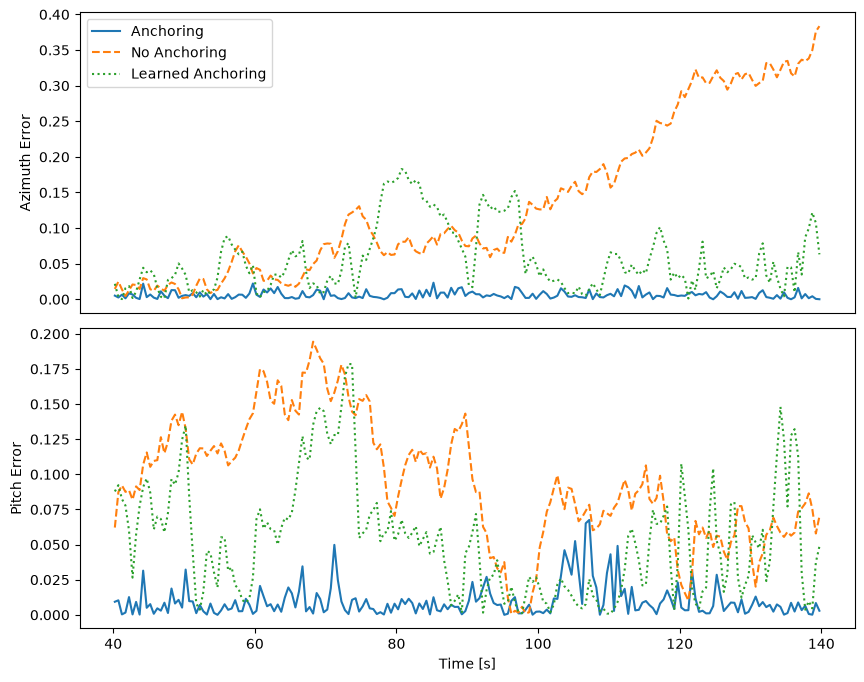

In [6]:
smooth_interval = 10
fig, ax = plt.subplots(
    nrows=2,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"hspace": (0.05)},
)
for angle_iter, angle in enumerate(["Azimuth", "Pitch"]):
    simple_anchor_error = angular_error(
        recording_anchor["decoded_angle"][:, angle_iter],
        high_noise_bat_flight["dir_torus"][::interval, angle_iter],
    )
    learned_anchor_error = angular_error(
        recording_learnt_anchor["decoded_angle"][:, angle_iter],
        high_noise_bat_flight["dir_torus"][::interval, angle_iter],
    )
    error = angular_error(
        recording["decoded_angle"][:, angle_iter],
        high_noise_bat_flight["dir_torus"][::interval, angle_iter],
    )
    ax[1 * angle_iter].plot(
        smooth_ts(high_noise_bat_flight["time"][::interval], smooth_interval),
        np.abs(smooth_ts(simple_anchor_error, smooth_interval)),
        label="Anchoring",
    )
    ax[1 * angle_iter].plot(
        smooth_ts(high_noise_bat_flight["time"][::interval], smooth_interval),
        np.abs(smooth_ts(error, smooth_interval)),
        label="No Anchoring",
        ls="--",
    )
    ax[1 * angle_iter].plot(
        smooth_ts(high_noise_bat_flight["time"][::interval], smooth_interval),
        np.abs(smooth_ts(learned_anchor_error, smooth_interval)),
        label="Learned Anchoring",
        ls=":",
    )
    ax[1 * angle_iter].set_ylabel(angle + " Error")

for axis_iter in range(len(ax) - 1):
    ax[axis_iter].get_xaxis().set_visible(False)


ax[0].legend()
ax[-1].set_xlabel("Time [s]")
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_anchoring_effect.svg"))

In [7]:
np.max(recording["conj_cells"]), np.max(
    recording_anchor["conj_cells"]
),np.max(
    recording_learnt_anchor["conj_cells"]
)

(np.float64(0.03239239378554575),
 np.float64(1.5294115587710506),
 np.float64(1.306116142255475))

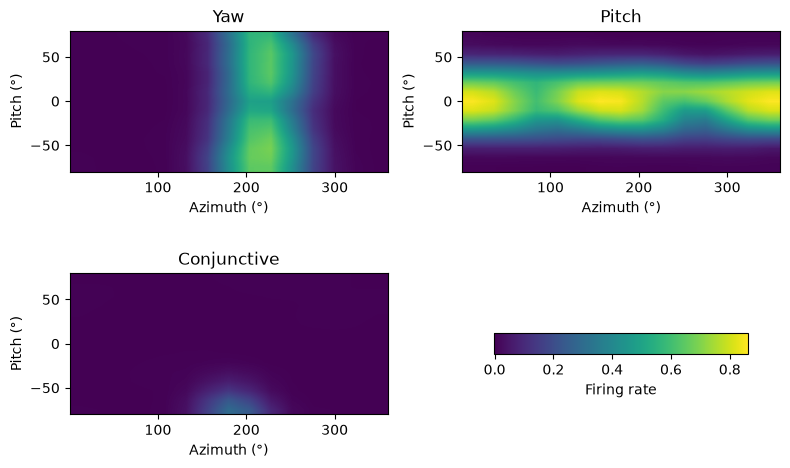

In [15]:
cell_index = 0
from grid_cells.plot_tools import activity_map

activities = [
    activity_map(
        high_noise_bat_flight["dir_torus"][::interval],
        recording_anchor["yaw_cells"][:, 100],
        nbins=15,
        sigma=1,
    ),
    activity_map(
        high_noise_bat_flight["dir_torus"][::interval],
        recording_anchor["pitch_cells"][:, 0],
        nbins=15,
        sigma=1,
    ),
    activity_map(
        high_noise_bat_flight["dir_torus"][::interval],
        recording_anchor["conj_cells"][:,100],
        nbins=15,
        sigma=1,
    ),
]
vmin = min([activity[0].min() for activity in activities])
vmax = max([activity[0].max() for activity in activities])

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(8, 5))
ax = ax.flatten()

for axis, (activity, _, direction_edges), title in zip(
    ax[:3], activities, ["Yaw", "Pitch", "Conjunctive"]
):
    image = axis.imshow(
        activity.T,
        extent=(
            direction_edges[0][0],
            direction_edges[0][-1],
            direction_edges[1][0],
            direction_edges[1][-1],
        ),
        origin="lower",
        interpolation="bilinear",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )
    axis.set_title(title)
    axis.set_xlabel("Azimuth (°)")
    axis.set_ylabel("Pitch (°)")
colorbar_ax = ax[3].inset_axes([0.1, 0.45, 0.8, 0.1])
fig.colorbar(image, cax=colorbar_ax, orientation="horizontal", label="Firing rate")
ax[3].axis("off")
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_cell_types.svg"))